In [1]:
import librosa
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
# Constantes globales — utilisées dans tout le notebook
SR = 22050          # Sample rate cible (Hz)
TARGET_LEN = SR * 6 # Durée fixe : 6 secondes
MIN_DURATION = 1.0  # Drop fichiers < 1 seconde

In [3]:
def load_dataset(data_dir='data'):
    x, y = [], []
    dropped = 0
    for label in sorted(os.listdir(data_dir)):
        label_dir = os.path.join(data_dir, label)
        if not os.path.isdir(label_dir):
            continue

        for file in os.listdir(label_dir):
            if not file.lower().endswith('.wav'):
                continue

            file_path = os.path.join(label_dir, file)

            duration = librosa.get_duration(path=file_path)
            if duration < MIN_DURATION:
                print(f"  Dropped: {file} ({duration:.2f}s)")
                dropped += 1
                continue

            audio, _ = librosa.load(file_path, sr=SR)
            x.append(audio.astype(np.float32))
            y.append(label)

    if not x:
        raise ValueError(f'No .wav files found in {data_dir}')

    print(f"Chargé : {len(x)} fichiers ({dropped} droppés)")
    return x, np.array(y)

x, y = load_dataset('data')

df = pd.DataFrame({'sound': x, 'label': y})
print('Nombre de fichiers:', len(x))
print('classes:', np.unique(y))

c:\Users\victor\Documents\ECOLE\5A\T2\AP1\HACKATHON FINAL\respiratory-disease-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Dropped: P20WheezingIE_97.wav (0.53s)
  Dropped: P22WheezingRL_107.wav (0.48s)
  Dropped: P2AsthmaIU_6.wav (0.66s)
Chargé : 1208 fichiers (3 droppés)
Nombre de fichiers: 1208
classes: ['Bronchial' 'asthma' 'copd' 'healthy' 'pneumonia']


In [4]:
df.head()

,sound,label
0,"[0.00341448, 0.00590638, 0.0069539696, 0.00855...",Bronchial
1,"[-0.024567118, -0.036486607, -0.033269316, -0....",Bronchial
2,"[0.00089291716, 0.0012487946, 0.0011123628, 0....",Bronchial
3,"[0.0073115397, 0.010985471, 0.009617966, 0.010...",Bronchial
4,"[-0.0039379024, -0.002399697, 0.002469554, 0.0...",Bronchial


Text(0.5, 1.0, 'Distribution des classes')

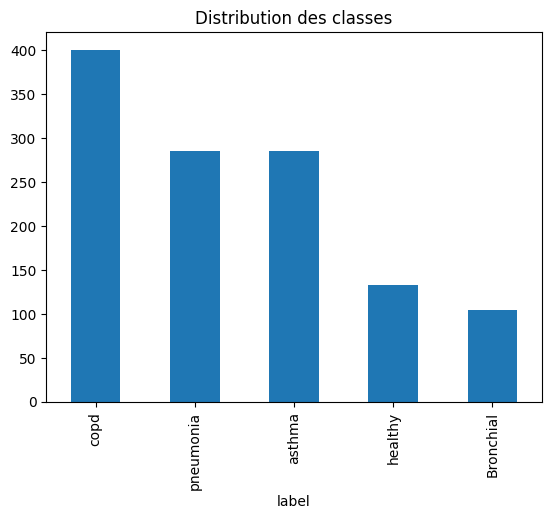

In [5]:
# Graphique de distribution des classes
df['label'].value_counts().plot(kind='bar')
plt.title('Distribution des classes')

## Q2 — Distribution des classes & déséquilibre

           count  percentage
label                       
copd         401        33.2
pneumonia    285        23.6
asthma       285        23.6
healthy      133        11.0
Bronchial    104         8.6

Total: 1208 samples

Ratio max/min classes: 3.9x


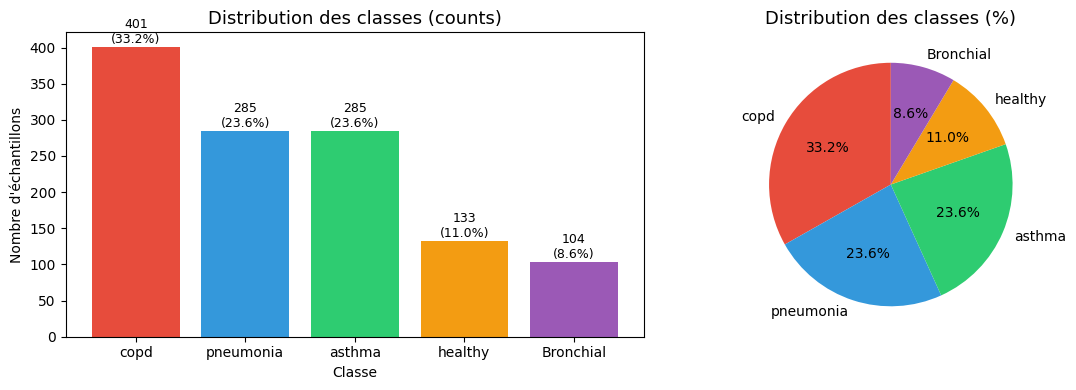

In [6]:
counts = df['label'].value_counts().sort_values(ascending=False)
percentages = (counts / len(df) * 100).round(1)

dist_df = pd.DataFrame({'count': counts, 'percentage': percentages})
print(dist_df.to_string())
print(f"\nTotal: {len(df)} samples")
print(f"\nRatio max/min classes: {counts.max()/counts.min():.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Distribution des classes (counts)', fontsize=13)
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre d\'échantillons')
for i, (v, p) in enumerate(zip(counts.values, percentages.values)):
    axes[0].text(i, v + 5, f'{v}\n({p}%)', ha='center', fontsize=9)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Distribution des classes (%)', fontsize=13)

plt.tight_layout()
plt.show()

## Q3 — Propriétés audio : durées, amplitudes, sample rates

In [7]:
real_durations = []
real_sr_list = []
labels_dur = []

for label in sorted(os.listdir('data')):
    label_dir = os.path.join('data', label)
    if not os.path.isdir(label_dir):
        continue
    for file in os.listdir(label_dir):
        if not file.lower().endswith('.wav'):
            continue
        path = os.path.join(label_dir, file)
        duration = librosa.get_duration(path=path)
        sr_native = librosa.get_samplerate(path)
        real_durations.append(duration)
        real_sr_list.append(sr_native)
        labels_dur.append(label)

dur_df = pd.DataFrame({'label': labels_dur, 'duration_s': real_durations, 'native_sr': real_sr_list})

print("=== Durées (secondes) ===")
print(dur_df['duration_s'].describe().round(2))
print(f"\nDurée < 5s : {(dur_df['duration_s'] < 5).sum()} fichiers ({(dur_df['duration_s'] < 5).mean()*100:.1f}%)")
print(f"Durée > 5s : {(dur_df['duration_s'] > 5).sum()} fichiers ({(dur_df['duration_s'] > 5).mean()*100:.1f}%)")
print(f"\n=== Sample rates natifs ===")
print(dur_df['native_sr'].value_counts())

=== Durées (secondes) ===
count    1211.00
mean        5.91
std         0.44
min         0.48
25%         6.00
50%         6.00
75%         6.00
max         6.00
Name: duration_s, dtype: float64

Durée < 5s : 33 fichiers (2.7%)
Durée > 5s : 1178 fichiers (97.3%)

=== Sample rates natifs ===
native_sr
44100    707
4000     504
Name: count, dtype: int64


In [8]:
print(dur_df['duration_s'].value_counts().sort_index().to_string())

duration_s
0.480000       1
0.528000       1
0.656000       1
2.000023       3
2.384000       1
2.832000       1
3.072000       1
3.136000       1
4.352000       1
4.356168       2
4.544830       1
4.617392       1
4.675442       2
4.748005       1
4.762517       1
4.777029       2
4.791542       1
4.806054       1
4.835079       1
4.878617       2
4.922154       1
4.936667       1
4.944000       3
4.965692       1
4.994717       1
5.009229       2
5.023741       1
5.038254       1
5.050000       1
5.067279       1
5.081791       1
5.088000       3
5.096304       1
5.125329       1
5.139841       1
5.184000       2
5.197891       2
5.212404       1
5.235692       1
5.299478       4
5.313991       1
5.328503       2
5.357528       2
5.360000       1
5.386553       1
5.415578       3
5.444603       1
5.450000       1
5.456000       1
5.459116       2
5.472000       1
5.488141       1
5.502653       1
5.536000       3
5.546190       2
5.568000       2
5.633265       1
5.676803       1
5.6

In [9]:
print(dur_df[dur_df['duration_s'] < 5]['duration_s'].sort_values().to_string())
short = dur_df[dur_df['duration_s'] < 3]
print(short[['label', 'duration_s']])

172     0.480000
159     0.528000
211     0.656000
83      2.000023
95      2.000023
103     2.000023
290     2.384000
287     2.832000
1108    3.072000
104     3.136000
250     4.352000
1056    4.356168
1096    4.356168
978     4.544830
838     4.617392
1087    4.675442
1085    4.675442
1090    4.748005
1080    4.762517
987     4.777029
971     4.777029
1142    4.791542
981     4.806054
985     4.835079
1055    4.878617
860     4.878617
1206    4.922154
990     4.936667
584     4.944000
297     4.944000
105     4.944000
1072    4.965692
1092    4.994717
         label  duration_s
83   Bronchial    2.000023
95   Bronchial    2.000023
103  Bronchial    2.000023
159     asthma    0.528000
172     asthma    0.480000
211     asthma    0.656000
287     asthma    2.832000
290     asthma    2.384000


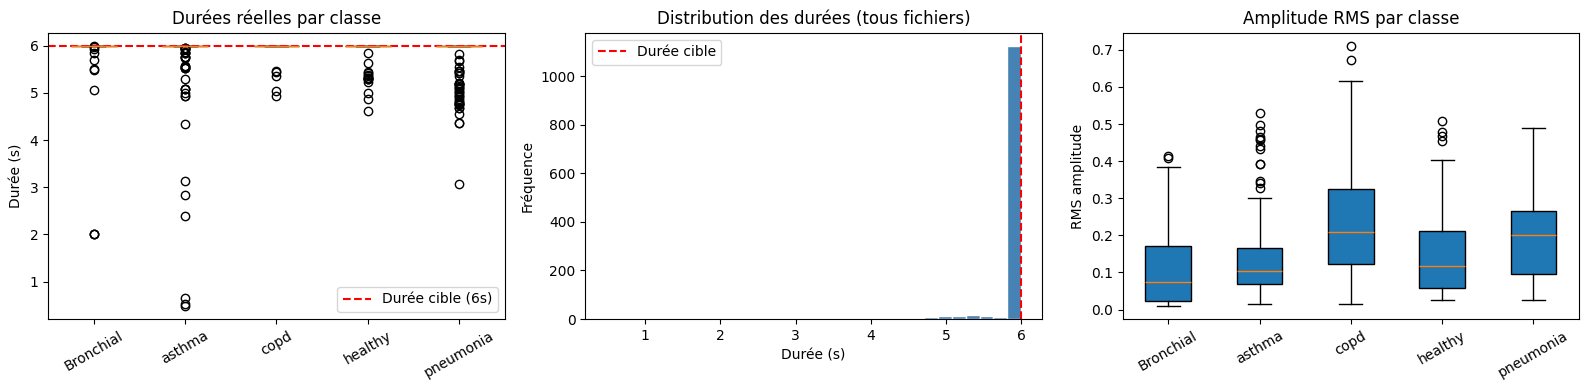

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

classes = dur_df['label'].unique()
data_by_class = [dur_df[dur_df['label'] == c]['duration_s'].values for c in classes]
axes[0].boxplot(data_by_class, tick_labels=classes, patch_artist=True)
axes[0].axhline(y=6, color='red', linestyle='--', label='Durée cible (6s)')
axes[0].set_title('Durées réelles par classe')
axes[0].set_ylabel('Durée (s)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

axes[1].hist(real_durations, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(x=6, color='red', linestyle='--', label='Durée cible')
axes[1].set_title('Distribution des durées (tous fichiers)')
axes[1].set_xlabel('Durée (s)')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

# Amplitude RMS par classe
rms_per_class = {}
for label in np.unique(y):
    indices = np.where(y == label)[0]
    rms = [np.sqrt(np.mean(x[i]**2)) for i in indices]
    rms_per_class[label] = rms

bp = axes[2].boxplot(rms_per_class.values(), tick_labels=rms_per_class.keys(), patch_artist=True)
axes[2].set_title('Amplitude RMS par classe')
axes[2].set_ylabel('RMS amplitude')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [11]:
print("=== Amplitude RMS par classe ===")
for label in np.unique(y):
    indices = np.where(y == label)[0]
    rms = np.array([np.sqrt(np.mean(x[i]**2)) for i in indices])
    print(f"{label:12s} — mean: {rms.mean():.4f}  std: {rms.std():.4f}  min: {rms.min():.4f}  max: {rms.max():.4f}")

print(f"\n=== Amplitude globale ===")
rms_all = np.array([np.sqrt(np.mean(audio**2)) for audio in x])
print(pd.Series(rms_all).describe().round(4).to_string())

=== Amplitude RMS par classe ===
Bronchial    — mean: 0.1151  std: 0.1139  min: 0.0092  max: 0.4125
asthma       — mean: 0.1309  std: 0.0925  min: 0.0156  max: 0.5310
copd         — mean: 0.2392  std: 0.1452  min: 0.0136  max: 0.7108
healthy      — mean: 0.1555  std: 0.1150  min: 0.0262  max: 0.5093
pneumonia    — mean: 0.1928  std: 0.1055  min: 0.0245  max: 0.4881

=== Amplitude globale ===
count    1208.0000
mean        0.1828
std         0.1281
min         0.0092
25%         0.0791
50%         0.1527
75%         0.2604
max         0.7108


## Q4 — Visualisation des formes d'onde et spectrogrammes par classe

In [12]:
from IPython.display import display, Audio

for label in np.unique(y):
    idx = np.where(y == label)[0][0]
    print(f"🔊 {label}")
    display(Audio(data=x[idx], rate=SR))

🔊 Bronchial


🔊 asthma


🔊 copd


🔊 healthy


🔊 pneumonia


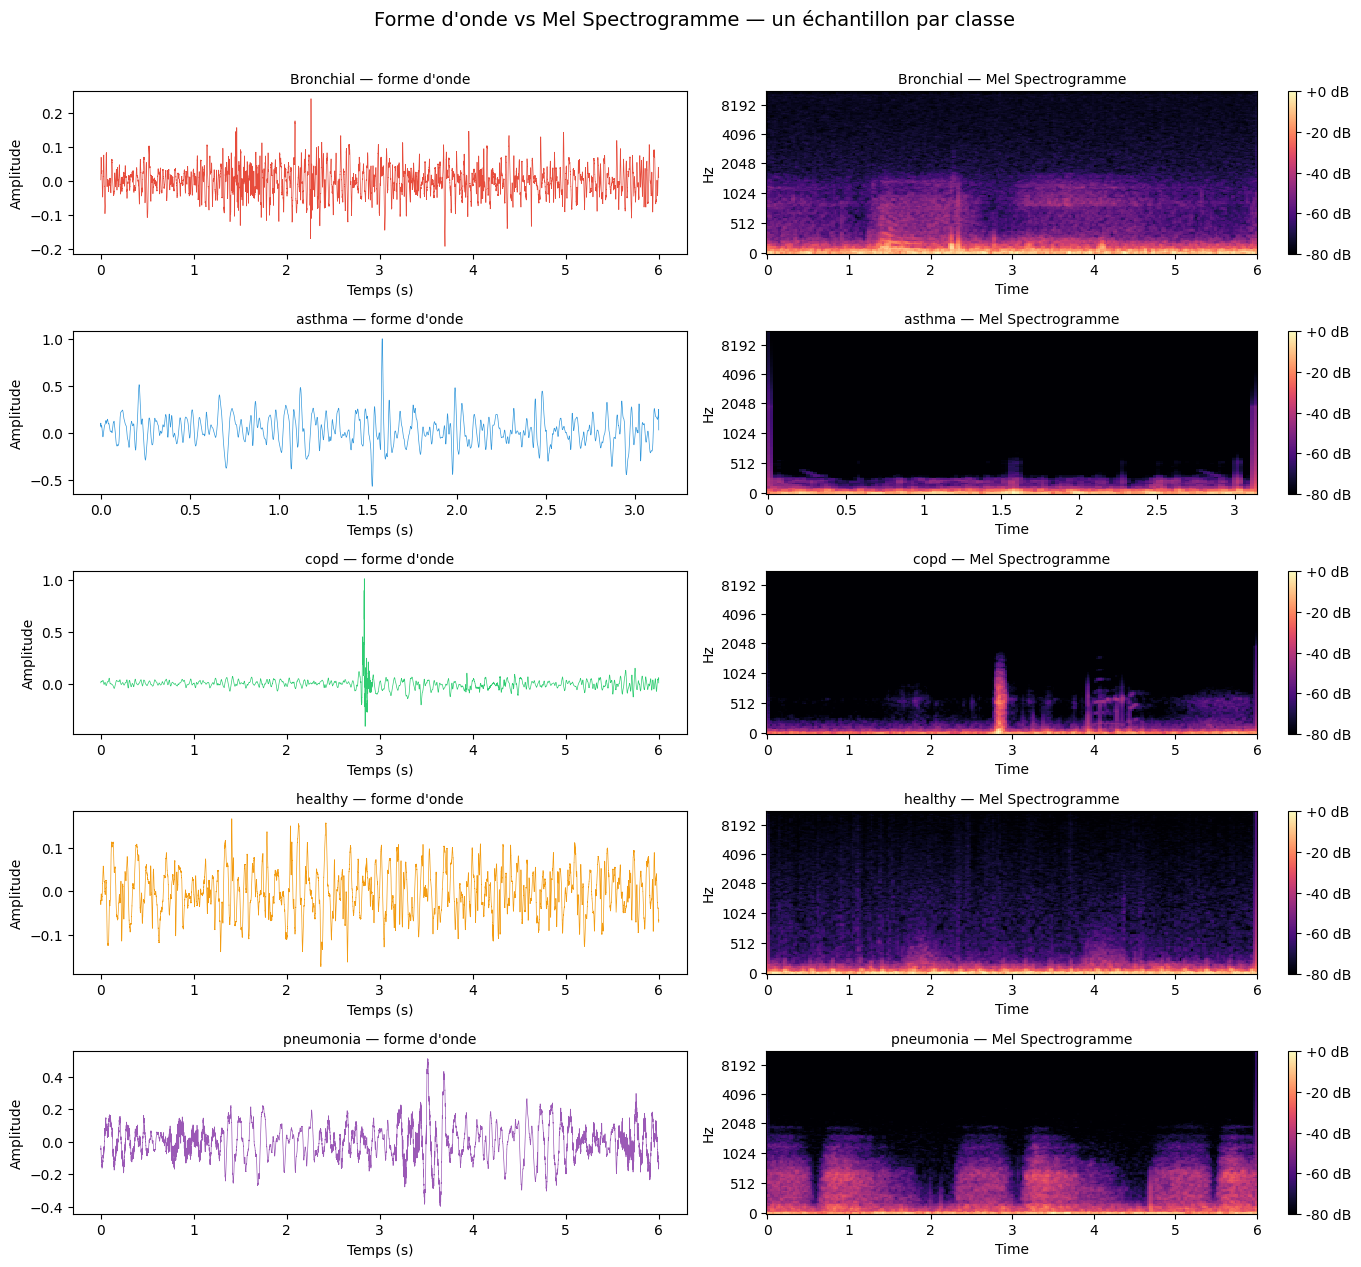

In [13]:
import librosa.display

labels_unique = sorted(np.unique(y))
fig, axes = plt.subplots(len(labels_unique), 2, figsize=(14, len(labels_unique) * 2.5))
fig.suptitle('Forme d\'onde vs Mel Spectrogramme — un échantillon par classe', fontsize=14, y=1.01)

for i, label in enumerate(labels_unique):
    idx = np.where(y == label)[0][0]
    audio = x[idx]
    duration = len(audio) / SR

    # Waveform
    axes[i, 0].plot(np.linspace(0, duration, len(audio)), audio, color=colors[i], linewidth=0.5)
    axes[i, 0].set_title(f'{label} — forme d\'onde', fontsize=10)
    axes[i, 0].set_xlabel('Temps (s)')
    axes[i, 0].set_ylabel('Amplitude')

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=128, n_fft=2048, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=SR, hop_length=512, x_axis='time', y_axis='mel', ax=axes[i, 1], cmap='magma')
    axes[i, 1].set_title(f'{label} — Mel Spectrogramme', fontsize=10)
    fig.colorbar(img, ax=axes[i, 1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

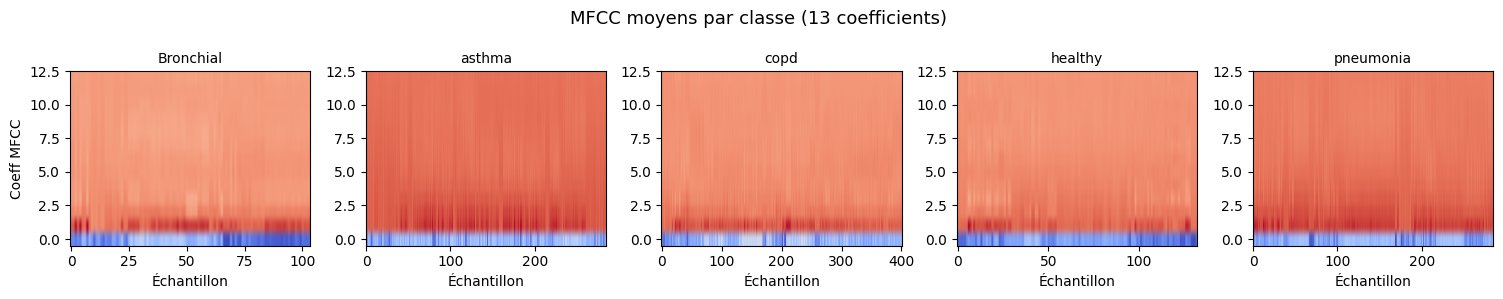

In [14]:
fig, axes = plt.subplots(1, len(labels_unique), figsize=(15, 3))
fig.suptitle('MFCC moyens par classe (13 coefficients)', fontsize=13)

for i, label in enumerate(labels_unique):
    indices = np.where(y == label)[0]
    mfccs_mean = []
    for idx in indices:
        mfcc = librosa.feature.mfcc(y=x[idx], sr=SR, n_mfcc=13)
        mfccs_mean.append(mfcc.mean(axis=1))
    mfccs_mean = np.array(mfccs_mean)

    axes[i].imshow(mfccs_mean.T, aspect='auto', origin='lower', cmap='coolwarm')
    axes[i].set_title(label, fontsize=10)
    axes[i].set_xlabel('Échantillon')
    axes[i].set_ylabel('Coeff MFCC' if i == 0 else '')

plt.tight_layout()
plt.show()

## Features acoustiques discriminantes — Spectral Centroid, ZCR, Spectral Bandwidth

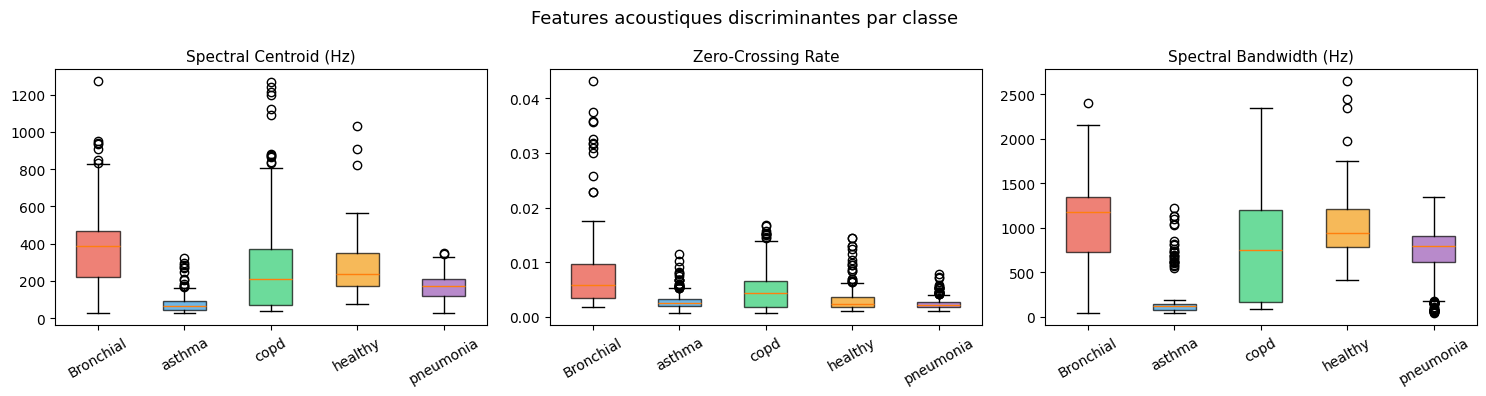

In [15]:
features_per_class = {label: {'centroid': [], 'zcr': [], 'bandwidth': []} for label in labels_unique}

for audio, label in zip(x, y):
    centroid = librosa.feature.spectral_centroid(y=audio, sr=SR).mean()
    zcr = librosa.feature.zero_crossing_rate(audio).mean()
    bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=SR).mean()
    features_per_class[label]['centroid'].append(centroid)
    features_per_class[label]['zcr'].append(zcr)
    features_per_class[label]['bandwidth'].append(bandwidth)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
feature_names = ['centroid', 'zcr', 'bandwidth']
titles = ['Spectral Centroid (Hz)', 'Zero-Crossing Rate', 'Spectral Bandwidth (Hz)']

for ax, feat, title in zip(axes, feature_names, titles):
    data = [features_per_class[l][feat] for l in labels_unique]
    bp = ax.boxplot(data, tick_labels=labels_unique, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Features acoustiques discriminantes par classe', fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
# Résumé statistique des features par classe
summary_rows = []
for label in labels_unique:
    for feat in feature_names:
        vals = features_per_class[label][feat]
        summary_rows.append({
            'classe': label,
            'feature': feat,
            'mean': np.mean(vals),
            'std': np.std(vals),
            'min': np.min(vals),
            'max': np.max(vals),
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.pivot_table(index='classe', columns='feature', values='mean').round(4).to_string())

feature    bandwidth  centroid     zcr
classe                                
Bronchial  1051.3847  385.0359  0.0091
asthma      173.7892   75.3134  0.0029
copd        753.7103  265.3035  0.0048
healthy    1041.4440  274.3177  0.0034
pneumonia   729.9709  166.0057  0.0024
